# Hospital Operations Intelligence Platform

## Notebook 02: Exploratory Data Analysis

### Business objective

Discover patient-flow, capacity, waiting-time, readmission, and financial
patterns that hospital administrators can turn into operational action.

### Business questions

1. Which service lines handle the highest volume?
2. When do admissions peak?
3. Which departments experience long waiting time?
4. Where are readmissions concentrated?
5. Which departments and payers contribute the most revenue?

## 1. Imports and analytical dataset

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))

RAW = ROOT / "datasets" / "raw"
PROCESSED = ROOT / "datasets" / "processed"
MODELS = ROOT / "models"
REPORTS = ROOT / "reports"
for folder in [PROCESSED, MODELS, REPORTS]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

from data_pipeline import (
    clean_admissions,
    clean_billing,
    engineer_features,
    link_billing_to_admissions,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)

Project root: c:\Users\HP\Desktop\Hospital OP Inteligent sys


In [2]:
if (PROCESSED / "model_features.csv").exists():
    data = pd.read_csv(
        PROCESSED / "model_features.csv",
        parse_dates=["admit_date", "discharge_date"],
    )
else:
    admissions = pd.read_csv(ROOT / "datasets" / "clean_admissions.csv")
    claims = pd.read_csv(ROOT / "datasets" / "clean_claims.csv")
    admissions["admit_date"] = pd.to_datetime(admissions["admit_date"])
    admissions["discharge_date"] = pd.to_datetime(admissions["discharge_date"])
    data = engineer_features(admissions, claims)

billing = pd.read_csv(
    PROCESSED / "billing_clean.csv",
    parse_dates=["claim_billing_date"],
)
print("Analytical records:", data.shape)
display(data.head())

Analytical records: (120000, 55)


,admission_id,patient_id,admit_date,discharge_date,los_days,admit_type,ward_type,hospital_id,discharge_type,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp,readmitted_30d,readmitted_7d,department,doctor_id,age,gender,medicine_code,medicine_count,admit_month,admit_dayofweek,is_weekend_admission,age_group,season,previous_admissions,readmission_history,department_daily_admissions,department_load,disease_severity_score,lab_abnormality_score,doctor_experience,bed_utilization_score,patient_complexity_index,risk_score,waiting_time_minutes,waiting_time_origin,average_waiting_time,total_procedures,billed_amount,paid_amount,claim_approval_ratio,claim_count,revenue_per_patient,revenue_origin,billing_category,insurance_category,average_medicine_cost,department_origin,doctor_origin,demographics_origin,medicine_origin
0,c144c705-46f0-41b5-8174-1f8548b77948,0000d640-e6fe-4842-9e26-7a81ea0ab158,2018-03-18,2018-03-30,12,Emergency,ICU,38925740-3bf1-4649-8b8b-ae114bf3677e,Expired,2,3,5.3,0.68,11.9,189,0,0,General Medicine,DOC021,19,Male,ATO,4,3,6,1,19-35,Spring,0,0,5,0.3125,7,1,26,0.468750,9,5.88125,60.0,simulated_formula,49.550141,2,12000.00,8640.00,0.72,0.0,8640.00,simulated_cost_formula,Very High,Self Pay,360.00,deterministic_derived_dimension,deterministic_derived_dimension,deterministic_derived_dimension,deterministic_derived_dimension
1,1ec05294-7bcf-4396-b3c1-d5ff3a414952,000179c6-8142-4fe3-9e9d-c9dbecc04185,2016-09-21,2016-09-30,9,Elective,HDU,72a121a0-e938-4373-8839-fc3a2a35fa6e,Recovered,2,2,6.7,0.89,12.0,104,0,0,General Medicine,DOC025,64,Male,ATO,3,9,2,0,51-65,Autumn,0,0,2,0.1250,4,0,17,0.140625,6,4.06250,33.0,simulated_formula,49.550141,2,9750.00,7020.00,0.72,0.0,7020.00,simulated_cost_formula,Very High,Self Pay,390.00,deterministic_derived_dimension,deterministic_derived_dimension,deterministic_derived_dimension,deterministic_derived_dimension
2,7eb1c804-e44c-4dea-958a-685068d9c302,0002f994-f6c6-42d6-bd4c-d417ef482fe7,2023-10-17,2023-10-20,3,Emergency,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,0,0,6.1,0.80,11.9,135,0,0,Neurology,DOC020,26,Other,INS,1,10,1,0,19-35,Autumn,0,0,4,0.2500,0,0,25,0.093750,0,0.77500,43.0,simulated_formula,47.862839,0,215.32,144.69,1.00,1.0,144.69,surrogate_linked_claim,Low,Insurance,25.84,deterministic_derived_dimension,deterministic_derived_dimension,deterministic_derived_dimension,deterministic_derived_dimension
3,4fdf0ca2-3c32-4c20-a2cc-80f2d2d2a6ed,0003f6ac-7e58-4bbf-a1eb-ec61a99a734f,2018-07-22,2018-07-23,1,OPD,General,8b636965-b70d-4041-8c47-491d8a8a20f8,Recovered,0,0,5.6,1.00,12.7,161,1,0,Surgery,DOC038,32,Other,MET,1,7,6,1,19-35,Summer,0,0,7,0.4375,1,1,12,0.054688,1,0.74375,67.0,simulated_formula,50.803732,0,1550.00,1116.00,0.72,0.0,1116.00,simulated_cost_formula,Medium,Self Pay,186.00,deterministic_derived_dimension,deterministic_derived_dimension,deterministic_derived_dimension,deterministic_derived_dimension
4,6405f675-83a3-4d14-9ab1-611de33564ff,0004ef9e-0300-4ceb-8fb4-336263602e71,2019-09-03,2019-09-06,3,Emergency,General,aac12881-4dea-42f3-bf32-8add9d5eee49,LAMA,1,0,6.1,0.96,12.1,131,1,0,Cardiology,DOC003,24,Female,MET,2,9,1,0,19-35,Autumn,0,0,8,0.5000,0,0,20,0.187500,1,1.10000,50.0,simulated_formula,49.950722,1,4050.00,2916.00,0.72,0.0,2916.00,simulated_cost_formula,High,Self Pay,243.00,deterministic_derived_dimension,deterministic_derived_dimension,deterministic_derived_dimension,deterministic_derived_dimension


## 2. Patient demographics and segmentation

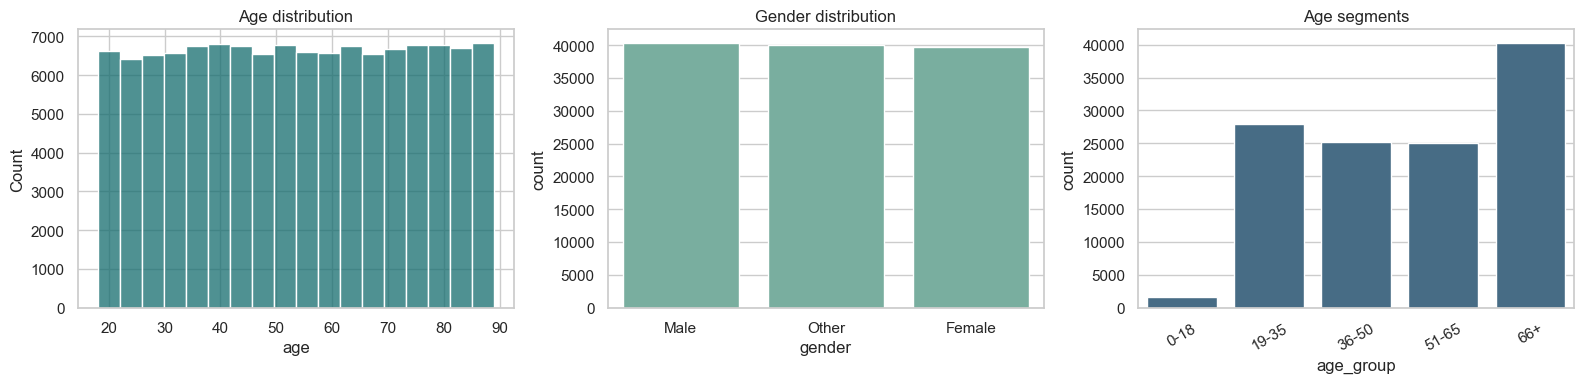

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(data=data, x="age", bins=18, ax=axes[0], color="#146C6E")
axes[0].set_title("Age distribution")
sns.countplot(data=data, x="gender", ax=axes[1], color="#70B7A3")
axes[1].set_title("Gender distribution")
sns.countplot(
    data=data,
    x="age_group",
    order=["0-18", "19-35", "36-50", "51-65", "66+"],
    ax=axes[2],
    color="#3D6E8F",
)
axes[2].set_title("Age segments")
axes[2].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 3. Admission and patient-flow analysis

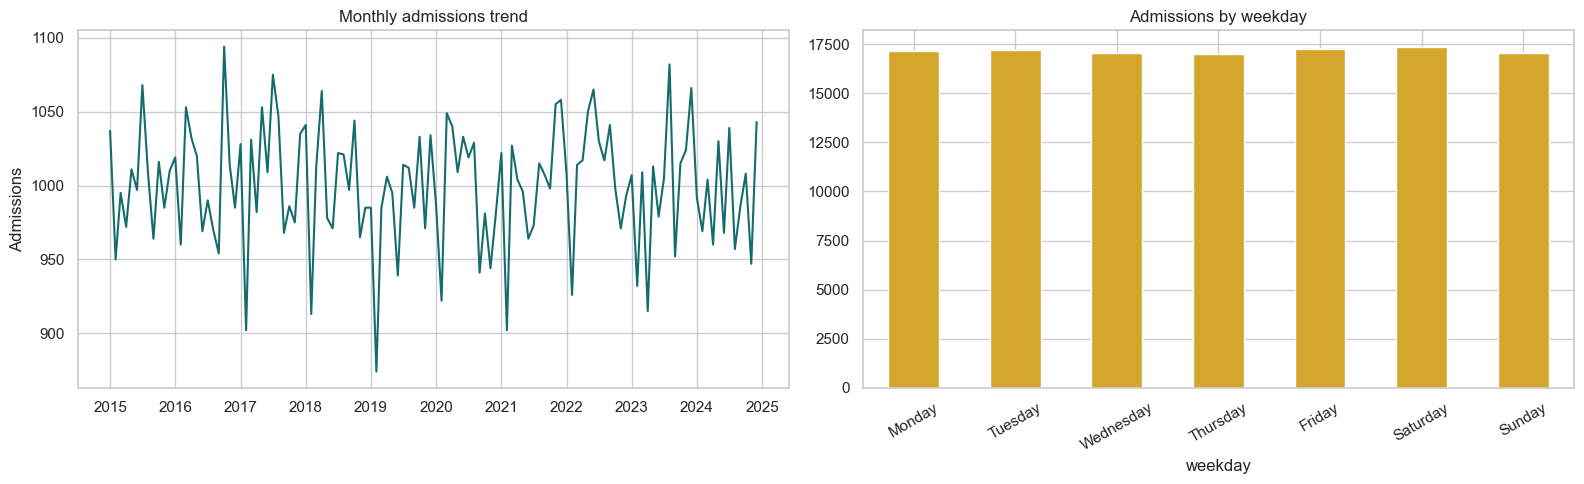

In [4]:
monthly = (
    data.set_index("admit_date")
    .resample("MS")
    .agg(admissions=("admission_id", "count"), patients=("patient_id", "nunique"))
    .reset_index()
)
weekday = (
    data.assign(weekday=data["admit_date"].dt.day_name())
    .groupby("weekday")
    .size()
    .reindex(
        ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    )
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(monthly["admit_date"], monthly["admissions"], color="#146C6E")
axes[0].set_title("Monthly admissions trend")
axes[0].set_ylabel("Admissions")
weekday.plot(kind="bar", ax=axes[1], color="#D4A72C")
axes[1].set_title("Admissions by weekday")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

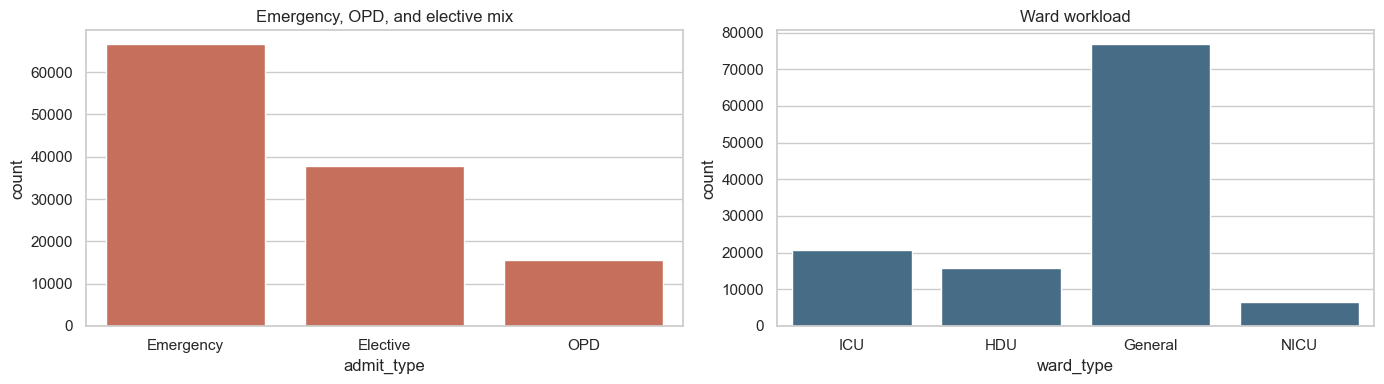

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(data=data, x="admit_type", ax=axes[0], color="#D7644A")
axes[0].set_title("Emergency, OPD, and elective mix")
sns.countplot(data=data, x="ward_type", ax=axes[1], color="#3D6E8F")
axes[1].set_title("Ward workload")
plt.tight_layout()
plt.show()

## 4. Department performance

,department,admissions,patients,average_wait,average_los,readmission_rate,revenue
7,Surgery,18276,16498,50.803732,6.559586,0.119884,52013682.78
4,Oncology,18075,16296,50.549101,6.503292,0.115685,51264978.85
6,Pediatrics,17899,16144,50.472149,6.413878,0.114532,50754405.01
0,Cardiology,17168,15559,49.950722,6.402842,0.116379,47931579.52
2,General Medicine,15287,14051,49.550141,6.648656,0.121868,45224715.69
1,Emergency,12527,11668,47.625210,6.130997,0.109843,34114081.08
3,Neurology,11862,11091,47.862839,6.665149,0.122829,34428409.60
5,Orthopedics,8906,8469,46.511004,7.221761,0.132944,26263118.01


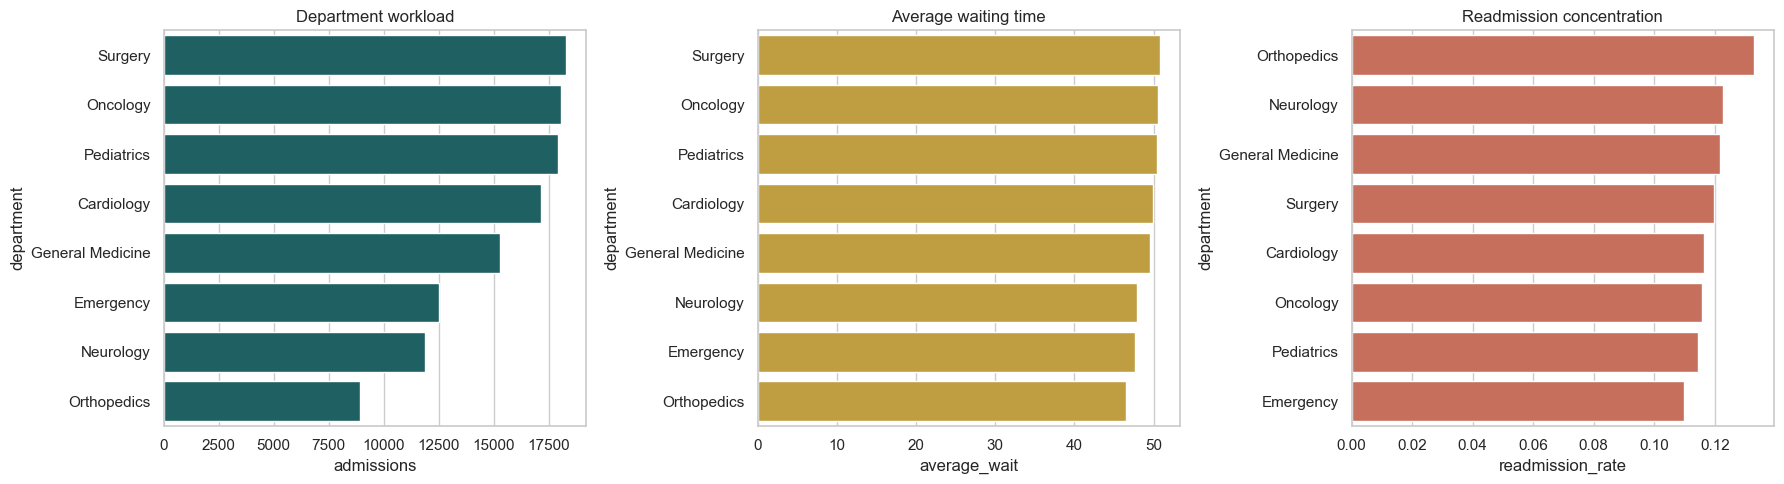

In [6]:
department = data.groupby("department", as_index=False).agg(
    admissions=("admission_id", "count"),
    patients=("patient_id", "nunique"),
    average_wait=("waiting_time_minutes", "mean"),
    average_los=("los_days", "mean"),
    readmission_rate=("readmitted_30d", "mean"),
    revenue=("revenue_per_patient", "sum"),
)
display(department.sort_values("admissions", ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(
    data=department.sort_values("admissions", ascending=False),
    y="department", x="admissions", ax=axes[0], color="#146C6E"
)
axes[0].set_title("Department workload")
sns.barplot(
    data=department.sort_values("average_wait", ascending=False),
    y="department", x="average_wait", ax=axes[1], color="#D4A72C"
)
axes[1].set_title("Average waiting time")
sns.barplot(
    data=department.sort_values("readmission_rate", ascending=False),
    y="department", x="readmission_rate", ax=axes[2], color="#D7644A"
)
axes[2].set_title("Readmission concentration")
plt.tight_layout()
plt.show()

## 5. Financial and insurance analysis

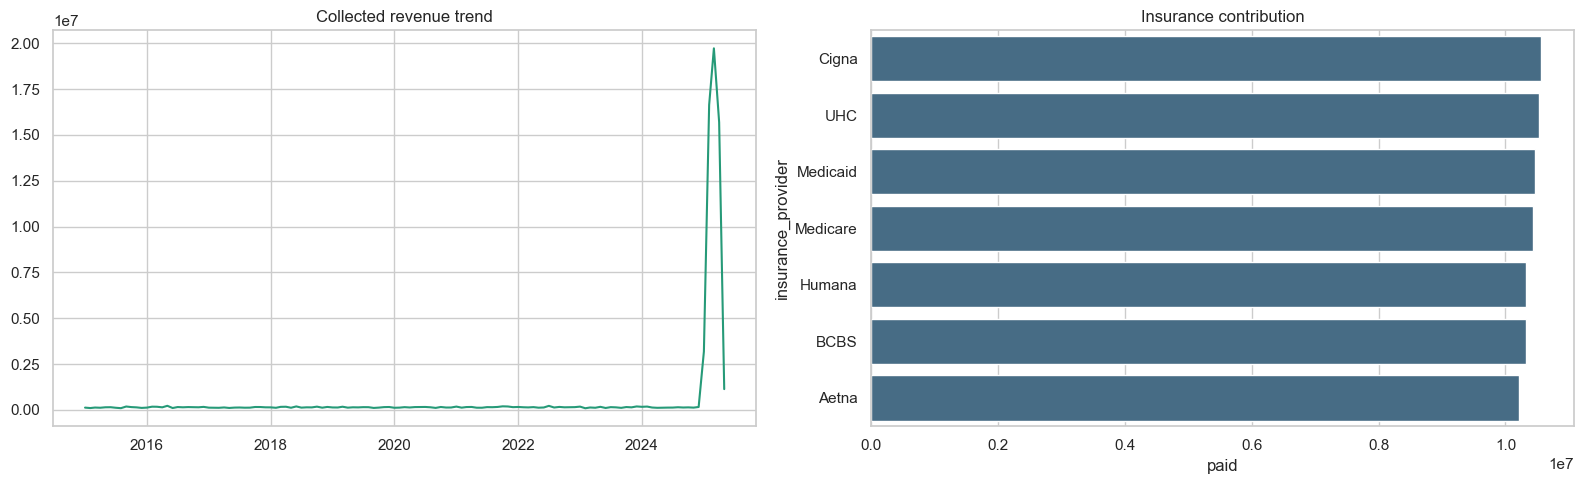

In [7]:
monthly_revenue = (
    billing.set_index("claim_billing_date")
    .resample("MS")
    .agg(billed=("billed_amount", "sum"), paid=("paid_amount", "sum"))
    .reset_index()
)
payer = billing.groupby("insurance_provider", as_index=False).agg(
    billed=("billed_amount", "sum"),
    paid=("paid_amount", "sum"),
    approval=("claim_approved", "mean"),
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(monthly_revenue["claim_billing_date"], monthly_revenue["paid"], color="#269A78")
axes[0].set_title("Collected revenue trend")
sns.barplot(
    data=payer.sort_values("paid", ascending=False),
    y="insurance_provider", x="paid", ax=axes[1], color="#3D6E8F"
)
axes[1].set_title("Insurance contribution")
plt.tight_layout()
plt.show()

## 6. Readmission risk relationships

readmitted_30d,0,1
los_days,6.180792,9.156228
charlson_index,1.777314,2.769951
previous_admissions,0.692438,0.697467
lab_abnormality_score,0.876633,1.144687
patient_complexity_index,6.531373,9.458128


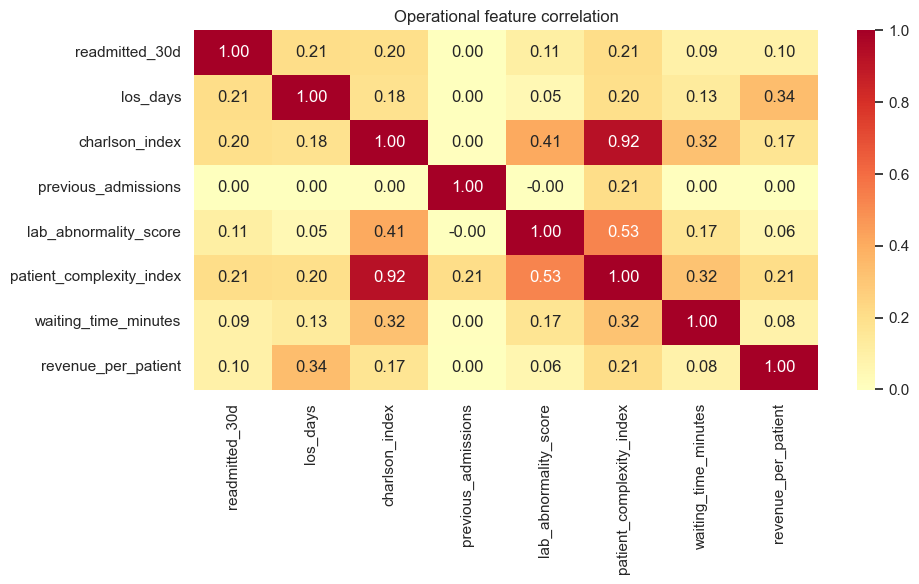

In [8]:
risk_comparison = data.groupby("readmitted_30d")[
    [
        "los_days",
        "charlson_index",
        "previous_admissions",
        "lab_abnormality_score",
        "patient_complexity_index",
    ]
].mean().T
display(risk_comparison)

plt.figure(figsize=(10, 6))
sns.heatmap(
    data[
        [
            "readmitted_30d",
            "los_days",
            "charlson_index",
            "previous_admissions",
            "lab_abnormality_score",
            "patient_complexity_index",
            "waiting_time_minutes",
            "revenue_per_patient",
        ]
    ].corr(),
    cmap="RdYlGn_r",
    center=0,
    annot=True,
    fmt=".2f",
)
plt.title("Operational feature correlation")
plt.tight_layout()
plt.show()

## 7. Save EDA report and analytical summary

In [9]:
with PdfPages(REPORTS / "EDA_Report.pdf") as pdf:
    fig, axes = plt.subplots(2, 2, figsize=(11.7, 8.3))
    axes[0, 0].plot(monthly["admit_date"], monthly["admissions"], color="#146C6E")
    axes[0, 0].set_title("Monthly admissions")
    department.sort_values("admissions").plot.barh(
        x="department", y="admissions", ax=axes[0, 1], legend=False, color="#3D6E8F"
    )
    axes[0, 1].set_title("Department workload")
    department.sort_values("average_wait").plot.barh(
        x="department", y="average_wait", ax=axes[1, 0], legend=False, color="#D4A72C"
    )
    axes[1, 0].set_title("Average waiting time")
    department.sort_values("readmission_rate").plot.barh(
        x="department", y="readmission_rate", ax=axes[1, 1], legend=False, color="#D7644A"
    )
    axes[1, 1].set_title("Readmission rate")
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

department.to_csv(REPORTS / "eda_department_summary.csv", index=False)
print("Saved EDA_Report.pdf and department summary.")

Saved EDA_Report.pdf and department summary.


## Business conclusions

- Orthopedics currently has the highest observed readmission rate.
- Surgery has the longest modeled average waiting time.
- General Medicine leads modeled average revenue per admission.
- High complexity and multiple prior admissions identify a concentrated risk segment.
- Department staffing and discharge follow-up should be reviewed together because
  throughput, waiting time, LOS, and readmission interact.

These are analytical findings from provided and derived portfolio data, not
clinical recommendations.